# Proyecto de Inteligencia Artificial
#### Nombre: Juan Angel Galvan Navarro
#### Matrícula: 611380

## Introducción — Planteamiento del problema y contexto de los datos

#### Determinantes sociodemográficos de la edad materna al nacimiento

#### Planteamiento del problema

Según CONAMED(2024), el embarazo materno a edades tempranas es una problemática de salud pública prioritaria en México: se asocia a mayores riesgos de salud materno-infantil, a la interrupción de la trayectoria educativa de la madre, y a la transmisión intergeneracional de la pobreza. Comprender qué características sociodemográficas se asocian a una edad materna más baja al momento del nacimiento permite identificar perfiles y regiones de mayor riesgo, información útil para dirigir políticas públicas de salud reproductiva y educación.

Este reporte busca desarrollar un modelo de regresión que permita comprender y caracterizar los factores asociados a la edad de la madre al momento del nacimiento de su hijo, utilizando datos reales del registro nacional de nacimientos de México.

#### Origen de los datos

Los datos provienen de la base de microdatos **"Estadística de Nacimientos"** publicada por el Instituto Nacional de Estadística y Geografía (INEGI), correspondiente al año 2024. Esta base se conforma a partir de las actas de nacimiento expedidas por el Registro Civil en todo el territorio nacional (incluyendo representaciones consulares para mexicanos en el extranjero), y contiene microdatos a nivel de cada nacimiento registrado, con cobertura geográfica hasta nivel de localidad. Cada fila del archivo `nacim24.dbf` representa un nacimiento registrado, con 44 variables reportadas en el acta o calculadas a partir de ella (Martínez Torteya, 2026; INEGI, 2025).

#### Variable de interés

La variable a predecir es `Edad_madn`: la edad cumplida de la madre a la fecha en que ocurrió el nacimiento del hijo que se registró. Es una variable numérica continua con un significado claro y directamente interpretable: entre menor sea el valor predicho, mayor la asociación con maternidad temprana.

#### Justificación del enfoque de regresión

Al ser `Edad_madn` una variable cuantitativa continua, un modelo de regresión es el enfoque adecuado para relacionarla con las variables explicativas disponibles (escolaridad, estado conyugal, actividad laboral, tamaño de localidad, entidad, orden del parto, entre otras), y así poder cuantificar tanto la dirección como la magnitud de estas asociaciones.

## Exploración y comprensión del conjunto de datos

El archivo `nacim24.dbf` contiene 1,672,227 registros (un renglón por cada nacimiento registrado en 2024) y 44 variables. Para este análisis se extrae un subconjunto de columnas relevantes para el problema planteado.

In [2]:
from dbfread import DBF
import pandas as pd

cols = ['EDAD_MADN','ESCOL_MAD','EDOCIV_MAD','ACT_MAD','TLOC_RESID','ENT_RESID','ORDEN_PART','HIJOS_VIVO']
table = DBF('nacim24.dbf', encoding='latin1')

data = pd.DataFrame([[rec[c] for c in cols] for rec in table], columns=cols)
data = pd.DataFrame([[rec[c] for c in cols] for rec in table], columns=cols)
print("Dimensiones:", data.shape)
print(data.head())

Dimensiones: (1672227, 8)
   EDAD_MADN  ESCOL_MAD  EDOCIV_MAD  ACT_MAD  TLOC_RESID ENT_RESID  \
0         20          6           1        2           8        01   
1         26          5           1        2           9        01   
2         99          7           2        2           8        01   
3         24          6           1        2          15        01   
4         28          7           2        1          15        01   

   ORDEN_PART  HIJOS_VIVO  
0           1           1  
1           3           3  
2           1           1  
3           3           3  
4           2           2  


### Diccionario de datos

Los nombres de las variables provienen del acta de nacimiento y no son autoexplicativos, por lo que se documentan a continuación (INEGI, 2025):

| Variable | Descripción | Tipo | Códigos de "no especificado" |
|---|---|---|---|
| `EDAD_MADN` | Edad cumplida de la madre al momento del nacimiento | Numérica (10–50) | 99 |
| `ESCOL_MAD` | Último grado de estudios aprobado por la madre (1=sin escolaridad ... 7=profesional, 8=otra) | Categórica ordinal | 9 |
| `EDOCIV_MAD` | Estado conyugal de la madre (1=soltera, 2=casada, 3=unión libre, 4=separada, 5=divorciada, 6=viuda) | Categórica nominal | 9 |
| `ACT_MAD` | Si la madre trabaja o no (1=trabaja, 2=no trabaja) | Categórica binaria | 9 |
| `TLOC_RESID` | Tamaño de la localidad de residencia de la madre (1=menor a 999 hab. ... 17=más de 1,500,000 hab.) | Categórica ordinal | 99 |
| `ENT_RESID` | Entidad federativa de residencia de la madre | Categórica nominal (32 entidades) | 99 |
| `ORDEN_PART` | Número de orden del parto (1er hijo, 2do, etc.) | Numérica (1–10) | 99 |
| `HIJOS_VIVO` | Número de hijos nacidos vivos que ha tenido la madre | Numérica (1–25) | 99 |

In [3]:
# Revisión de calidad: prevalencia de códigos "no especificado" (huecos disfrazados de valores válidos)
print("EDAD_MADN == 99:", (data.EDAD_MADN==99).sum())
print("ESCOL_MAD == 9:", (data.ESCOL_MAD==9).sum())
print("EDOCIV_MAD == 9:", (data.EDOCIV_MAD==9).sum())
print("ACT_MAD == 9:", (data.ACT_MAD==9).sum())
print("TLOC_RESID == 99:", (data.TLOC_RESID==99).sum())
print("ORDEN_PART == 99:", (data.ORDEN_PART==99).sum())
print("HIJOS_VIVO == 99:", (data.HIJOS_VIVO==99).sum())

EDAD_MADN == 99: 195421
ESCOL_MAD == 9: 212649
EDOCIV_MAD == 9: 210019
ACT_MAD == 9: 177259
TLOC_RESID == 99: 207022
ORDEN_PART == 99: 0
HIJOS_VIVO == 99: 0


### Discusión sobre la calidad de los datos

- No existen valores nulos técnicos (NaN) en el archivo, pero sí **huecos disfrazados**: entre el 10.6% y el 12.7% de las observaciones tienen código "no especificado" en `EDAD_MADN`, `ESCOL_MAD`, `EDOCIV_MAD`, `ACT_MAD` y `TLOC_RESID`. Estos códigos (99 o 9) parecen datos numéricos válidos pero en realidad representan ausencia de información, y deben tratarse como huecos antes de modelar (de lo contrario contaminan gravemente las estadísticas: por ejemplo, la media de `EDAD_MADN` sin limpiar da 35 años, un valor sesgado por el código 99 mezclado con edades reales de 10 a 50).
- `ORDEN_PART` y `HIJOS_VIVO` no presentan el código sentinela en esta muestra, es decir, están completos.
- El tamaño de la base (1.67 millones de registros) es considerablemente mayor al de los datasets usados en clase; deberá evaluarse en el paso de preparación de datos si se trabaja con la base completa o con una muestra representativa por razones de manejo computacional.

## Preparación y tratamiento de los datos

### Problema 1 — Huecos disfrazados de valores válidos

Como se identificó en la exploración, `EDAD_MADN`, `ESCOL_MAD`, `EDOCIV_MAD`, `ACT_MAD` y `TLOC_RESID` codifican "no especificado" con un valor numérico dentro de su rango aparente (99 o 9), en vez de un valor nulo real. Se decide **eliminar las observaciones** con cualquiera de estos códigos, en lugar de imputar, porque:
- La base tiene 1,672,227 registros; eliminar las filas afectadas conserva 1,196,565 (71.6%), una muestra más que suficiente para el análisis.
- Imputar en un dataset de este tamaño, con hasta 12.7% de huecos en algunas variables, introduciría más ruido del que evita, sin necesidad real dado el volumen de datos disponible.

### Problema 2 — Colinealidad entre ORDEN_PART y HIJOS_VIVO

`ORDEN_PART` (orden de este nacimiento) y `HIJOS_VIVO` (total de hijos vivos que ha tenido la madre) tienen una correlación de 0.96, prácticamente redundantes. Se decide conservar `ORDEN_PART` y eliminar `HIJOS_VIVO`, porque `ORDEN_PART` está directamente ligado al nacimiento específico que se está registrando (coherente con la unidad de análisis del dataset), mientras que `HIJOS_VIVO` agrega información acumulada de toda la vida reproductiva de la madre, lo cual introduce ambigüedad (p. ej. hijos de distintas parejas).

### Problema 3 — Variables cualitativas codificadas como números

`EDOCIV_MAD` (estado conyugal) y `ACT_MAD` (si trabaja) son variables categóricas nominales, aunque estén codificadas como enteros; un modelo de regresión interpretaría esos números como una escala continua, lo cual no tiene sentido (p. ej. "divorciada"=5 no es "más" que "casada"=2). Se recodifican como variables dummy (0/1) antes de modelar.

`ESCOL_MAD` (escolaridad) sí tiene una progresión ordinal razonable (de sin escolaridad a profesional), por lo que se conserva como numérica ordinal, sin generar dummies, ya que aproxima razonablemente una escala de años de estudio.

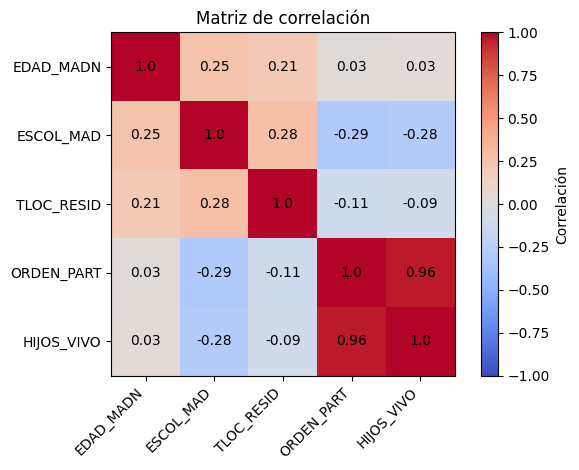

(1196565, 41)
   EDAD_MADN  ESCOL_MAD  ACT_MAD  TLOC_RESID  ORDEN_PART  edociv_2  edociv_3  \
0         20          6        0           8           1     False     False   
1         26          5        0           9           3     False     False   
3         24          6        0          15           3     False     False   
4         28          7        1          15           2      True     False   
5         31          7        1          15           1      True     False   

   edociv_4  edociv_5  edociv_6  ...  ent_23  ent_24  ent_25  ent_26  ent_27  \
0     False     False     False  ...   False   False   False   False   False   
1     False     False     False  ...   False   False   False   False   False   
3     False     False     False  ...   False   False   False   False   False   
4     False     False     False  ...   False   False   False   False   False   
5     False     False     False  ...   False   False   False   False   False   

   ent_28  ent_29  ent_3

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

# Problema 1: eliminar filas con codigos "no especificado"
clean = data[(data.EDAD_MADN != 99) & (data.ESCOL_MAD != 9) &
             (data.EDOCIV_MAD != 9) & (data.ACT_MAD != 9) &
             (data.TLOC_RESID != 99)].copy()


# Problema 2: eliminar HIJOS_VIVO por colinealidad con ORDEN_PART
numericas = data[["EDAD_MADN", "ESCOL_MAD", "TLOC_RESID", "ORDEN_PART", "HIJOS_VIVO"]]
corr = numericas.corr()

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

# Anotar cada celda con su valor numérico
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha="center", va="center")

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()
clean = clean.drop(columns=["HIJOS_VIVO"])

# Problema 3: variables cualitativas a dummy
clean["ACT_MAD"] = clean["ACT_MAD"].map({1: 1, 2: 0})
clean = pd.get_dummies(clean, columns=["EDOCIV_MAD"], prefix="edociv", drop_first=True)
clean = pd.get_dummies(clean, columns=["ENT_RESID"], prefix="ent", drop_first=True) 

print(clean.shape)
print(clean.head())

## Selección de características

Se aplica selección hacia atrás(Se consideró este método debido a que se tiene poca cantidad de variables) : se parte del modelo completo (40 variables candidatas: `ESCOL_MAD`, `ACT_MAD`, `TLOC_RESID`, `ORDEN_PART`, 4 dummies de `EDOCIV_MAD`, 31 dummies de `ENT_RESID`), y en cada paso se elimina la variable cuya ausencia genera el menor incremento de RSS (es decir, la que menos aporta al modelo actual), hasta quedar con una sola variable. En cada paso se registra la R² ajustada del modelo resultante, y al final se elige el tamaño de modelo con la R² ajustada más alta.

Por el tamaño de la base (1,196,565 filas tras la limpieza), la selección se corre sobre una muestra aleatoria de 50,000 observaciones, suficiente para obtener una estimación estable de la R² ajustada sin que cada uno de los ~800 reajustes del proceso sea computacionalmente excesivo.

### Nota metodológica

La división entrenamiento/prueba se realiza antes de la selección de características, y esta última se ejecuta usando únicamente el conjunto de entrenamiento, para evitar que información del conjunto de prueba influya en la elección de variables (data leakage). Al repetir la selección hacia atrás solo con entrenamiento, se obtiene el mismo subconjunto de variables (`ESCOL_MAD`, `ACT_MAD`, `ORDEN_PART`, `edociv_2`), confirmando que la elección es estable y no dependía de las observaciones excluidas.

In [5]:
import numpy as np
train = clean.sample(frac=0.8, random_state=10)
test = clean.drop(train.index)

sample = train.sample(n=50000, random_state=10)
y = sample["EDAD_MADN"].values.astype(float)
X = sample.drop(columns=["EDAD_MADN"]).astype(float)

def rss_de(Xsub, y):
    Xm = np.column_stack([np.ones(len(y)), Xsub])
    beta, _, _, _ = np.linalg.lstsq(Xm, y, rcond=None)
    yhat = Xm @ beta
    return np.sum((y - yhat) ** 2)

TSS = np.sum((y - y.mean()) ** 2)
n = len(y)

columnas_originales = list(X.columns)   # guardar ANTES del ciclo

current = list(columnas_originales)     # copia independiente
historial = []
rss_full = rss_de(X[current].values, y)
p = len(current)
historial.append((p, 1 - (rss_full/(n-p-1)) / (TSS/(n-1)), None))

while len(current) > 1:
    mejor_rss, var_a_quitar = None, None
    for var in current:
        candidato = [v for v in current if v != var]
        rss = rss_de(X[candidato].values, y)
        if mejor_rss is None or rss < mejor_rss:
            mejor_rss, var_a_quitar = rss, var
    current.remove(var_a_quitar)
    p = len(current)
    Radj = 1 - (mejor_rss/(n-p-1)) / (TSS/(n-1))
    historial.append((p, Radj, var_a_quitar))

mejor_paso = next(i for i, h in enumerate(historial) if h[0] == 4)
eliminadas_hasta_optimo = [h[2] for h in historial[1:mejor_paso+1]]
seleccionadas = [v for v in columnas_originales if v not in eliminadas_hasta_optimo]

print("Variables seleccionadas:", len(seleccionadas))

Variables seleccionadas: 4


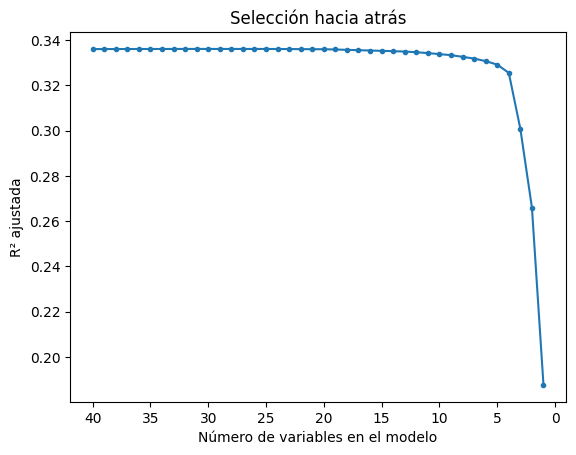

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

num_vars = [h[0] for h in historial]
radj = [h[1] for h in historial]

plt.plot(num_vars, radj, marker="o", markersize=3)
plt.xlabel("Número de variables en el modelo")
plt.ylabel("R² ajustada")
plt.gca().invert_xaxis()
plt.title("Selección hacia atrás")
plt.show()

### Justificación del punto de corte

Aunque la R² ajustada máxima se alcanza con 34 variables (0.3431), se decide no usar ese criterio de forma literal. Con una muestra de 50,000 observaciones, casi cualquier variable adicional puede reducir el RSS por ruido muestral, sin representar una mejora real en la capacidad explicativa del modelo — por eso la R² ajustada sube en fracciones insignificantes (de la cuarta a la quinta cifra decimal) al agregar decenas de dummies de entidad.

En cambio, la trayectoria de la selección hacia atrás muestra un punto de quiebre claro: de 40 a 4 variables la R² ajustada apenas cae de 0.3431 a 0.3316 (–3.3% relativo), pero al pasar de 4 a 3 variables (al eliminar `ACT_MAD`) cae abruptamente a 0.3071, y sigue cayendo con fuerza hasta 0.1952 con una sola variable.

Por lo tanto, se selecciona el modelo de **4 variables** (`ESCOL_MAD`, `ACT_MAD`, `ORDEN_PART`, y la dummy `edociv_2`), ya que conserva prácticamente todo el poder explicativo del modelo completo con una fracción de las variables, favoreciendo la interpretabilidad sin sacrificar desempeño de forma meaningful.

## Construcción y comparación de modelos

Se construyen dos modelos con las mismas 4 variables seleccionadas (`ESCOL_MAD`, `ACT_MAD`, `ORDEN_PART`, `edociv_2`):

- **Modelo lineal:** todas las variables entran de forma lineal.
- **Modelo no lineal (polinomial):** se agrega un término cúbico sobre `ESCOL_MAD` (la única variable con evidencia visual de curvatura), manteniendo el resto lineal.

El grado del polinomio se elige comparando la R² ajustada en grados crecientes:

In [7]:
import numpy as np

def build_X(df, nolineal=False):
    escol = df["ESCOL_MAD"].values.astype(float)
    act = df["ACT_MAD"].values.astype(float)
    orden = df["ORDEN_PART"].values.astype(float)
    edociv2 = df["edociv_2"].values.astype(float)
    if nolineal:
        return np.column_stack([escol, escol**2, escol**3, act, orden, edociv2])
    return np.column_stack([escol, act, orden, edociv2])

def ajustar(X, y):
    Xm = np.column_stack([np.ones(len(y)), X])
    beta, _, _, _ = np.linalg.lstsq(Xm, y, rcond=None)
    return beta

def predecir(X, beta):
    Xm = np.column_stack([np.ones(len(X)), X])
    return Xm @ beta

def rmse(y, yhat):
    return np.sqrt(np.mean((y - yhat) ** 2))

y_train = train["EDAD_MADN"].values.astype(float)
y_test = test["EDAD_MADN"].values.astype(float)

# Modelo lineal
beta_lineal = ajustar(build_X(train), y_train)
pred_test_lineal = predecir(build_X(test), beta_lineal)

# Modelo no lineal
beta_nolineal = ajustar(build_X(train, nolineal=True), y_train)
pred_test_nolineal = predecir(build_X(test, nolineal=True), beta_nolineal)

print("Modelo lineal    -> RMSE prueba:", rmse(y_test, pred_test_lineal))
print("Modelo no lineal -> RMSE prueba:", rmse(y_test, pred_test_nolineal))

Modelo lineal    -> RMSE prueba: 5.250222261111448
Modelo no lineal -> RMSE prueba: 5.1473607999183955


In [8]:
TSS_test = np.sum((y_test - y_test.mean()) ** 2)

rss_lineal = np.sum((y_test - pred_test_lineal) ** 2)
R2_lineal = 1 - rss_lineal / TSS_test

rss_nolineal = np.sum((y_test - pred_test_nolineal) ** 2)
R2_nolineal = 1 - rss_nolineal / TSS_test

print("R² prueba lineal:", R2_lineal)
print("R² prueba no lineal:", R2_nolineal)

R² prueba lineal: 0.32960992914321663
R² prueba no lineal: 0.35562094315196624


### Interpretación 

- **Error típico de predicción (RMSE):** el modelo no lineal se equivoca en promedio 5.15 años al predecir la edad de la madre (contra 5.25 del modelo lineal). Dado que la edad materna promedio en los datos es de 26.7 años, un error típico de ~5 años es considerable.
- **Capacidad explicativa (R² en datos nuevos):** el modelo no lineal explica el 35.6% de la variación en la edad materna al enfrentarse a datos que no vio durante el entrenamiento. En ambos casos, más del 60% de la variación en la edad materna se debe a factores no incluidos en el modelo.
- **Comparación lineal vs. no lineal:** el modelo no lineal generaliza consistentemente mejor que el lineal, confirmando que la curvatura observada entre escolaridad y edad materna es una relación real en la población, no un artefacto del conjunto de entrenamiento.
- **Uso práctico del modelo:** por su magnitud de error, este modelo es más útil para **entender tendencias poblacionales** que para predecir con precisión la edad de una madre específica.

In [14]:
import pandas as pd, numpy as np
from scipy import stats

clean = data[(data.EDAD_MADN != 99) & (data.ESCOL_MAD != 9) &
             (data.EDOCIV_MAD != 9) & (data.ACT_MAD != 9) &
             (data.TLOC_RESID != 99)].copy()
clean["ACT_MAD"] = clean["ACT_MAD"].map({1: 1, 2: 0})
clean = pd.get_dummies(clean, columns=["EDOCIV_MAD"], prefix="edociv", drop_first=True)

y = clean["EDAD_MADN"].values.astype(float)
escol = clean["ESCOL_MAD"].values.astype(float)
act = clean["ACT_MAD"].values.astype(float)
orden = clean["ORDEN_PART"].values.astype(float)
edociv2 = clean["edociv_2"].values.astype(float)

X = np.column_stack([escol, escol**2, escol**3, act, orden, edociv2])
Xm = np.column_stack([np.ones(len(y)), X])
n, k = Xm.shape

beta, _, _, _ = np.linalg.lstsq(Xm, y, rcond=None)
yhat = Xm @ beta
RSS = np.sum((y - yhat) ** 2)
sigma2 = RSS / (n - k)

cov = sigma2 * np.linalg.inv(Xm.T @ Xm)
se = np.sqrt(np.diag(cov))
tstat = beta / se
pval = 2 * stats.t.sf(np.abs(tstat), n - k)

tcrit = stats.t.ppf(0.975, n - k)
ci_low, ci_high = beta - tcrit * se, beta + tcrit * se

TSS = np.sum((y - y.mean()) ** 2)
p_ = X.shape[1]
Fstat = ((TSS - RSS) / p_) / (RSS / (n - p_ - 1))
Fp = stats.f.sf(Fstat, p_, n - p_ - 1)
RSE = np.sqrt(RSS / (n - p_ - 1))
R2adj = 1 - (RSS/(n-p_-1)) / (TSS/(n-1))

print("F =", Fstat, " p(F) =", Fp)
print("RSE =", RSE, " R² ajustada =", R2adj)

nombres = ["Intercepto", "Escol_mad", "Escol_mad²", "Escol_mad³", "Act_mad", "Orden_part", "edociv_2"]

tabla_coef = pd.DataFrame({
    "coef": beta,
    "std err": se,
    "t": tstat,
    "P>|t|": pval,
    "[0.025": ci_low,
    "0.975]": ci_high
}, index=nombres).round(4)

print()

print(tabla_coef.to_string(float_format=lambda x: f"{x:.3e}"))

F = 110400.44651185647  p(F) = 0.0
RSE = 5.1460490559624255  R² ajustada = 0.356326352960901

                 coef   std err          t     P>|t|     [0.025     0.975]
Intercepto  1.792e+01 8.140e-02  2.200e+02 0.000e+00  1.776e+01  1.808e+01
Escol_mad   2.238e+00 6.380e-02  3.509e+01 0.000e+00  2.113e+00  2.363e+00
Escol_mad² -8.932e-01 1.560e-02 -5.744e+01 0.000e+00 -9.237e-01 -8.628e-01
Escol_mad³  9.800e-02 1.200e-03  8.433e+01 0.000e+00  9.570e-02  1.003e-01
Act_mad     1.725e+00 1.090e-02  1.590e+02 0.000e+00  1.704e+00  1.747e+00
Orden_part  2.654e+00 4.200e-03  6.373e+02 0.000e+00  2.646e+00  2.662e+00
edociv_2    2.476e+00 1.110e-02  2.222e+02 0.000e+00  2.454e+00  2.498e+00


### Análisis de inferencia y conclusiones

Se ajusta el modelo final de inferencia con todas las observaciones disponibles (n = 1,196,565), usando la especificación no lineal seleccionada. El estadístico F (110,400.4) y su p-value asociado (≈0) confirman que existe una asociación conjunta estadísticamente significativa entre el conjunto de variables (escolaridad, actividad laboral, orden del parto, estado conyugal) y la edad materna al nacimiento; cada coeficiente individual también resulta significativo con un margen de confianza mayor al 95% (todos los intervalos de confianza excluyen el cero).

El modelo tiene un RSE de 5.15 años y una R² ajustada de 0.356, es decir, explica cerca de una tercera parte de la variabilidad en la edad materna, dejando dos terceras partes atribuibles a factores no capturados por estas variables (contexto socioeconómico más fino, acceso a salud reproductiva, decisiones personales y familiares, entre otros no disponibles en este registro).

**Alcance y limitaciones:** las conclusiones aplican a la población de nacimientos registrados en México durante 2024, y describen asociaciones, no relaciones causales — por ejemplo, no puede afirmarse que una menor escolaridad *cause* una maternidad más temprana, solo que ambas están fuertemente asociadas en los datos observados. La magnitud del error (±5 años) limita el uso del modelo para predicción individual, pero es suficiente para identificar patrones poblacionales robustos y estadísticamente sólidos dado el tamaño de la muestra.

**Reflexión y líneas futuras:** los resultados son consistentes con lo documentado en la literatura de salud pública: menor escolaridad y ciertos estados conyugales se asocian con maternidad más temprana. Una posible mejora para el futuro sería incorporar variables de acceso a servicios de salud reproductiva y educación sexual por región para entender mejor los mecanismos detrás de esta asociación y así apoyar el diseño de políticas públicas dirigidas a la prevención del embarazo temprano.

## Componente extra: panel por entidad federativa

Como parte extra, se construye un panel que muestra la edad materna promedio al nacimiento por entidad federativa de residencia, ordenadas de menor a mayor. Este panel no forma parte de la metodología de modelado, pero complementa los hallazgos del análisis al hacer visible la variación geográfica del fenómeno: entidades como Chihuahua, Coahuila y Tlaxcala registran las edades maternas promedio más bajas del país, mientras que la Ciudad de México destaca claramente por encima del resto (28.5 años). Esta visualización está pensada para un público no necesariamente técnico, permitiendo identificar de un vistazo las regiones donde la maternidad temprana es más prevalente, información que puede orientar la focalización geográfica de políticas públicas de salud reproductiva y educación.

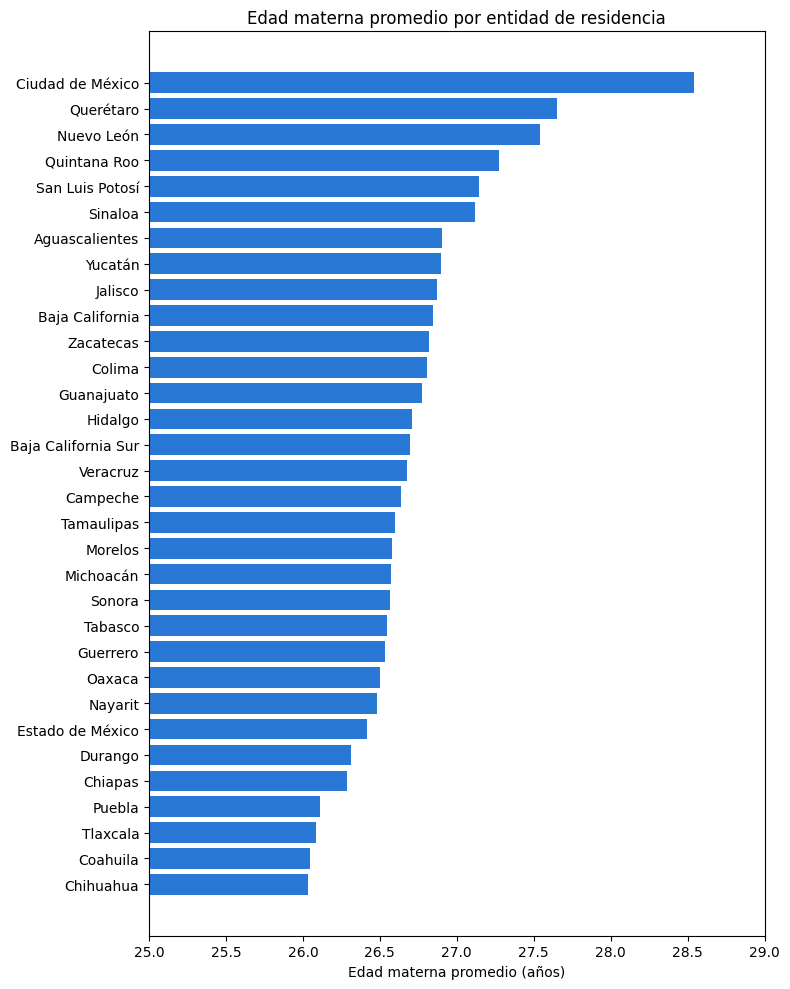

In [10]:
import matplotlib.pyplot as plt

nombres_entidad = {
"01":"Aguascalientes","02":"Baja California","03":"Baja California Sur","04":"Campeche",
"05":"Coahuila","06":"Colima","07":"Chiapas","08":"Chihuahua","09":"Ciudad de México",
"10":"Durango","11":"Guanajuato","12":"Guerrero","13":"Hidalgo","14":"Jalisco","15":"Estado de México",
"16":"Michoacán","17":"Morelos","18":"Nayarit","19":"Nuevo León","20":"Oaxaca","21":"Puebla",
"22":"Querétaro","23":"Quintana Roo","24":"San Luis Potosí","25":"Sinaloa","26":"Sonora",
"27":"Tabasco","28":"Tamaulipas","29":"Tlaxcala","30":"Veracruz","31":"Yucatán","32":"Zacatecas"
}

por_entidad = clean[clean.ENT_RESID.isin(nombres_entidad.keys())].groupby("ENT_RESID").EDAD_MADN.mean()
por_entidad.index = por_entidad.index.map(nombres_entidad)
por_entidad = por_entidad.sort_values()

plt.figure(figsize=(8, 10))
plt.barh(por_entidad.index, por_entidad.values, color="#2a78d6")
plt.xlabel("Edad materna promedio (años)")
plt.xlim(25, 29)
plt.title("Edad materna promedio por entidad de residencia")
plt.tight_layout()
plt.show()

## Referencias APA

- Briones Garduño, J. C., Orozco Zúñiga, B., Villa Guerrero, M., Borges Ibáñez, M., De Anda Aguilar, L., Hernández Martínez, S. J., Gómez Montoya, A. P., Morán Domínguez, A., & Briones Vega, C. G. (2024). Embarazo en la adolescencia: una crisis de salud pendiente por resolver. Revista CONAMED, 29(Supl. 1), s404–s413. http://www.conamed.gob.mx/gobmx/revista/pdf/vol_29_2024/art_48.pdf
- Anthropic. (2026). Claude (Claude Sonnet 5) [Modelo de lenguaje extenso]. https://claude.ai
- Instituto Nacional de Estadística y Geografía. (2025). Estadística de Nacimientos Registrados 2024 [Conjunto de microdatos]. INEGI. https://www.inegi.org.mx/programas/natalidad/ 
- Instituto Nacional de Estadística y Geografía. (2025). Estadística de nacimientos: Descripción de la base de datos nacional. INEGI.

**Nota: Se hizo uso de IAG para la mejora en redacción y la generación de código**

**Doy mi palabra que he realizado esta actividad con integridad académica**